In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [2]:
data = pd.read_csv('D:\Đại học\Ds108 - Tiền xử lý dữ liệu\Scraping\data\Silver_layer\cleaned_file_1.csv')
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\2725578940.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv('D:\Đại học\Ds108 - Tiền xử lý dữ liệu\Scraping\data\Silver_layer\cleaned_file_1.csv')


,id,brand,price,destination,hand_luggage,checked_baggage,start_hour,end_hour,trip_mins,is_holiday,days_left
0,PQC0002,Bamboo Airways,1245267,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,2,1
1,PQC0323,Vietravel Airlines,1224930,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,2,1
2,PQC0292,Vietnam Airlines,1535463,Phú Quốc (PQC)\nSân bay Phú Quốc,12,23,Evening,Evening,60,2,1
3,PQC0109,VietJet Air,1567000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Afternoon,Evening,60,2,1
4,PQC0132,VietJet Air,1567000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,65,2,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46628 entries, 0 to 46627
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               46628 non-null  object
 1   brand            46628 non-null  object
 2   price            46628 non-null  int64 
 3   destination      46628 non-null  object
 4   hand_luggage     46628 non-null  int64 
 5   checked_baggage  46628 non-null  int64 
 6   start_hour       46628 non-null  object
 7   end_hour         46628 non-null  object
 8   trip_mins        46628 non-null  int64 
 9   is_holiday       46628 non-null  int64 
 10  days_left        46628 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 3.9+ MB


In [4]:
data = data[~(data['days_left'] == 0)]

# EDA

In [5]:
data.describe()

,price,hand_luggage,checked_baggage,trip_mins,is_holiday,days_left
count,4.654900e+04,46549.000000,46549.000000,46549.000000,46549.000000,46549.000000
mean,2.066625e+06,9.219532,10.357022,99.895594,0.985864,10.535694
std,7.058187e+05,2.460549,11.413462,28.300063,0.986337,5.935772
min,6.902700e+05,7.000000,0.000000,45.000000,0.000000,1.000000
25%,1.592995e+06,7.000000,0.000000,80.000000,0.000000,6.000000
50%,1.945053e+06,7.000000,0.000000,115.000000,1.000000,10.000000
75%,2.436792e+06,12.000000,23.000000,125.000000,2.000000,15.000000
max,6.217970e+06,12.000000,23.000000,145.000000,3.000000,34.000000


In [6]:
data[['price','trip_mins','hand_luggage', 'checked_baggage','is_holiday','days_left']].corr().T
# data[['price','hand_luggage', 'checked_baggage','is_holiday','days_left']].corr().T

,price,trip_mins,hand_luggage,checked_baggage,is_holiday,days_left
price,1.000000,0.638637,0.234485,0.303908,0.330780,-0.080941
trip_mins,0.638637,1.000000,-0.106102,-0.065423,0.007924,-0.013652
hand_luggage,0.234485,-0.106102,1.000000,0.953567,-0.004511,0.010405
checked_baggage,0.303908,-0.065423,0.953567,1.000000,0.023982,-0.011791
is_holiday,0.330780,0.007924,-0.004511,0.023982,1.000000,0.056852
days_left,-0.080941,-0.013652,0.010405,-0.011791,0.056852,1.000000


In [7]:
data['brand'].unique()

array(['Bamboo Airways', 'Vietravel Airlines', 'Vietnam Airlines',
       'VietJet Air'], dtype=object)

In [8]:
data = pd.get_dummies(data, columns=['start_hour', 'end_hour', 'hand_luggage', 'checked_baggage'])

In [9]:
# Split data based on brand
Bamboo = data[data['brand'] == 'Bamboo Airways']
Vietjet = data[data['brand'] == 'VietJet Air']
Vietnam = data[data['brand'] == 'Vietnam Airlines']
Vietravel = data[data['brand'] == 'Vietravel Airlines']

**BAMBOO**

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def lineplot(data):
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 15))
    axes = axes.flatten()

    i = 0
    for des in data['destination'].unique():
        print(f'Destination: {des}, count: {len(data[data["destination"] == des])}')
        df = data[data['destination'] == des]
        sns.lineplot(ax=axes[i], x='days_left', y='price', data=df, color='blue')
        axes[i].set_title(f'{df["brand"].unique()[0]} - {des}')
        axes[i].set_xlabel('Days Left')
        axes[i].set_ylabel('Price')
        i += 1

    # Ẩn các subplot còn thừa nếu có
    for j in range(i, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 242
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 581
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 1883
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 201
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 225


) missing from font(s) DejaVu Sans.ykernel_26500\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


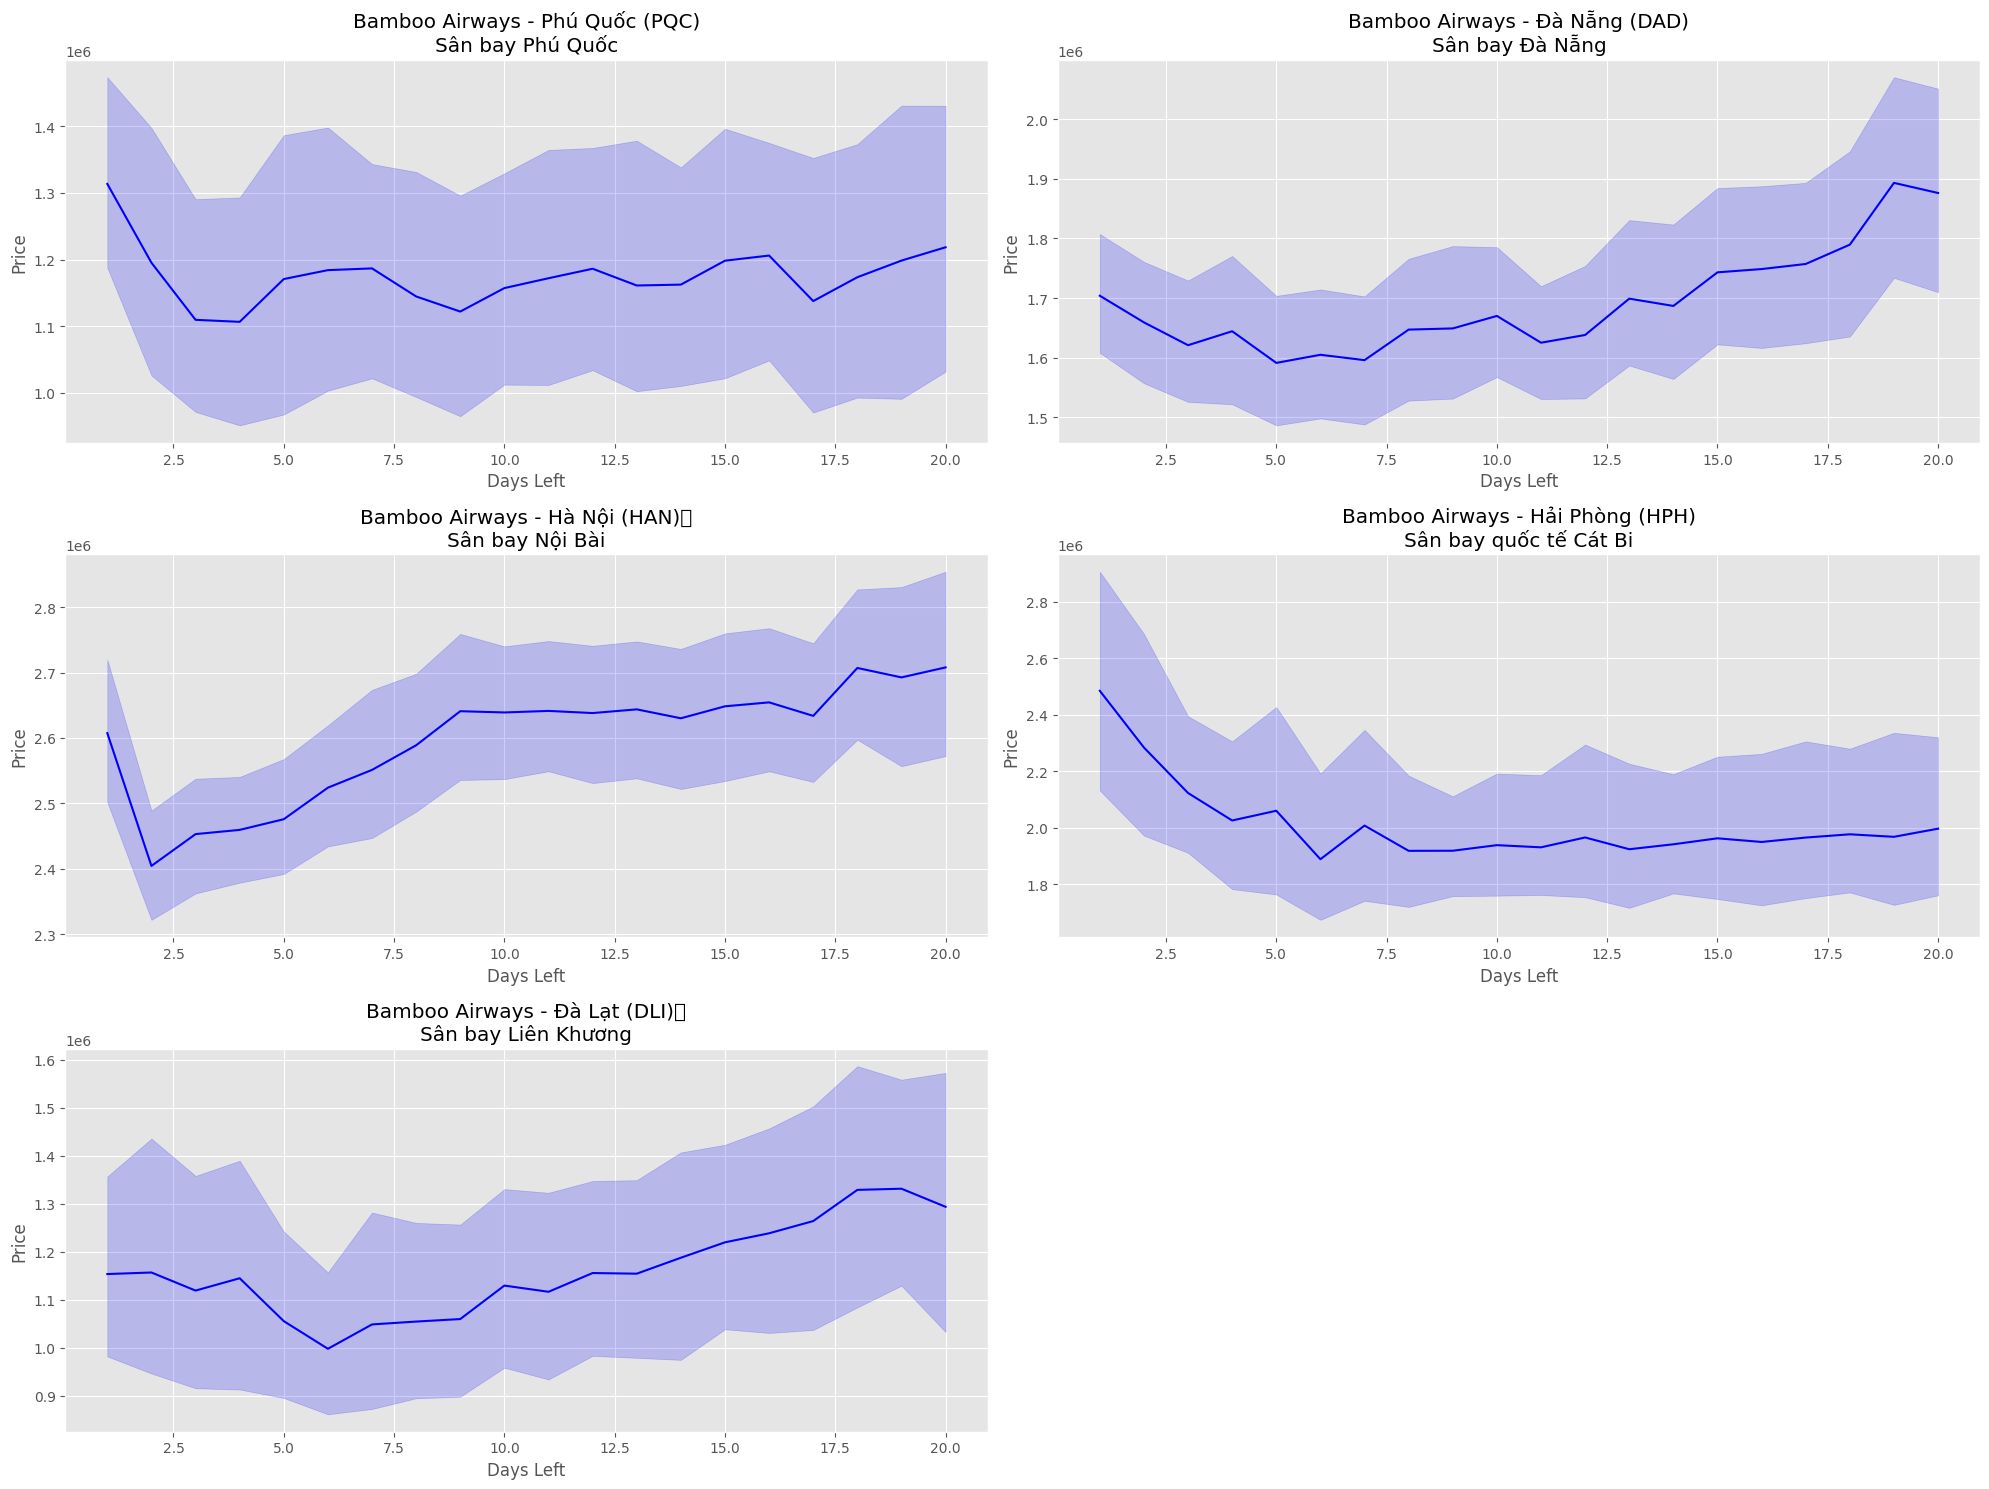

In [11]:
lineplot(Bamboo[Bamboo['days_left'] <= 20])

**Vietravel**

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 370
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 383
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 380


) missing from font(s) DejaVu Sans.ykernel_26500\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


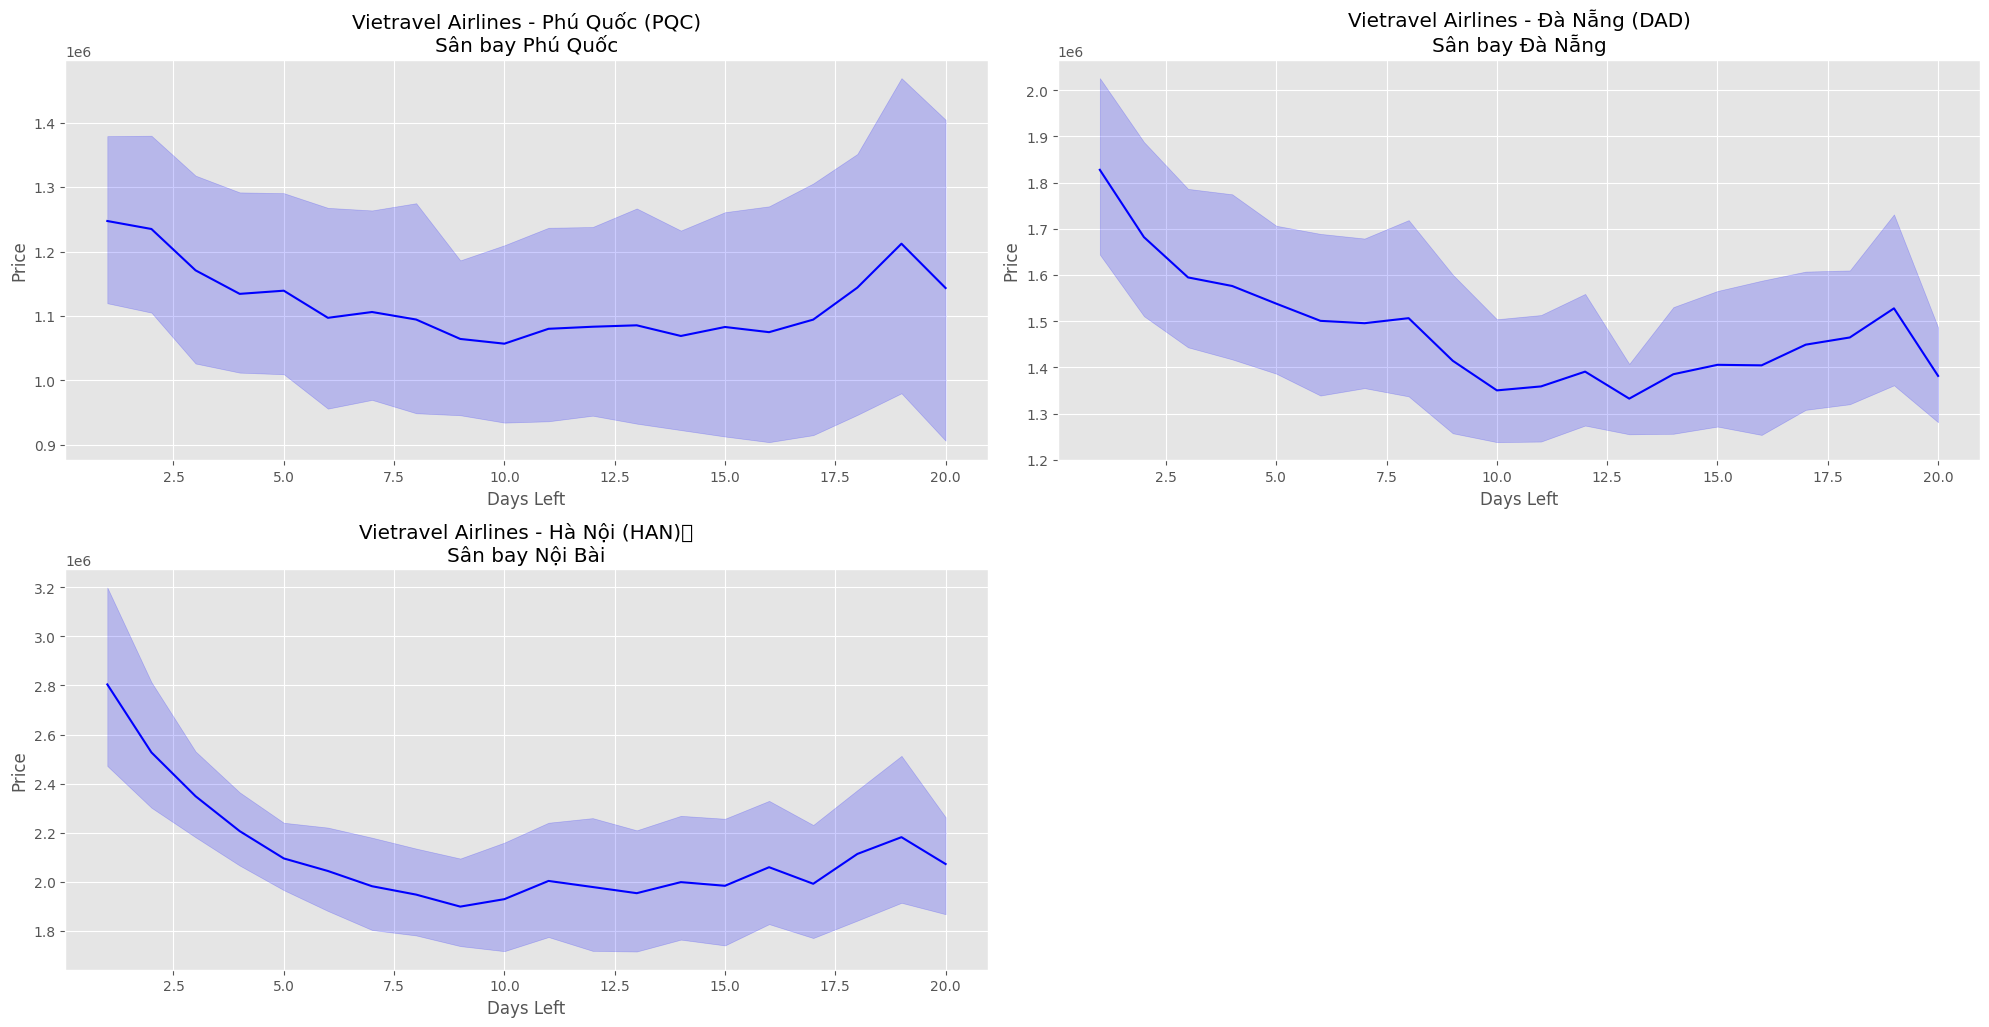

In [12]:
lineplot(Vietravel[Vietravel['days_left'] <= 20])

**Vietjet**

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 2214
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 5340
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 8837
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 2645
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 486
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 1121


) missing from font(s) DejaVu Sans.ykernel_26500\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


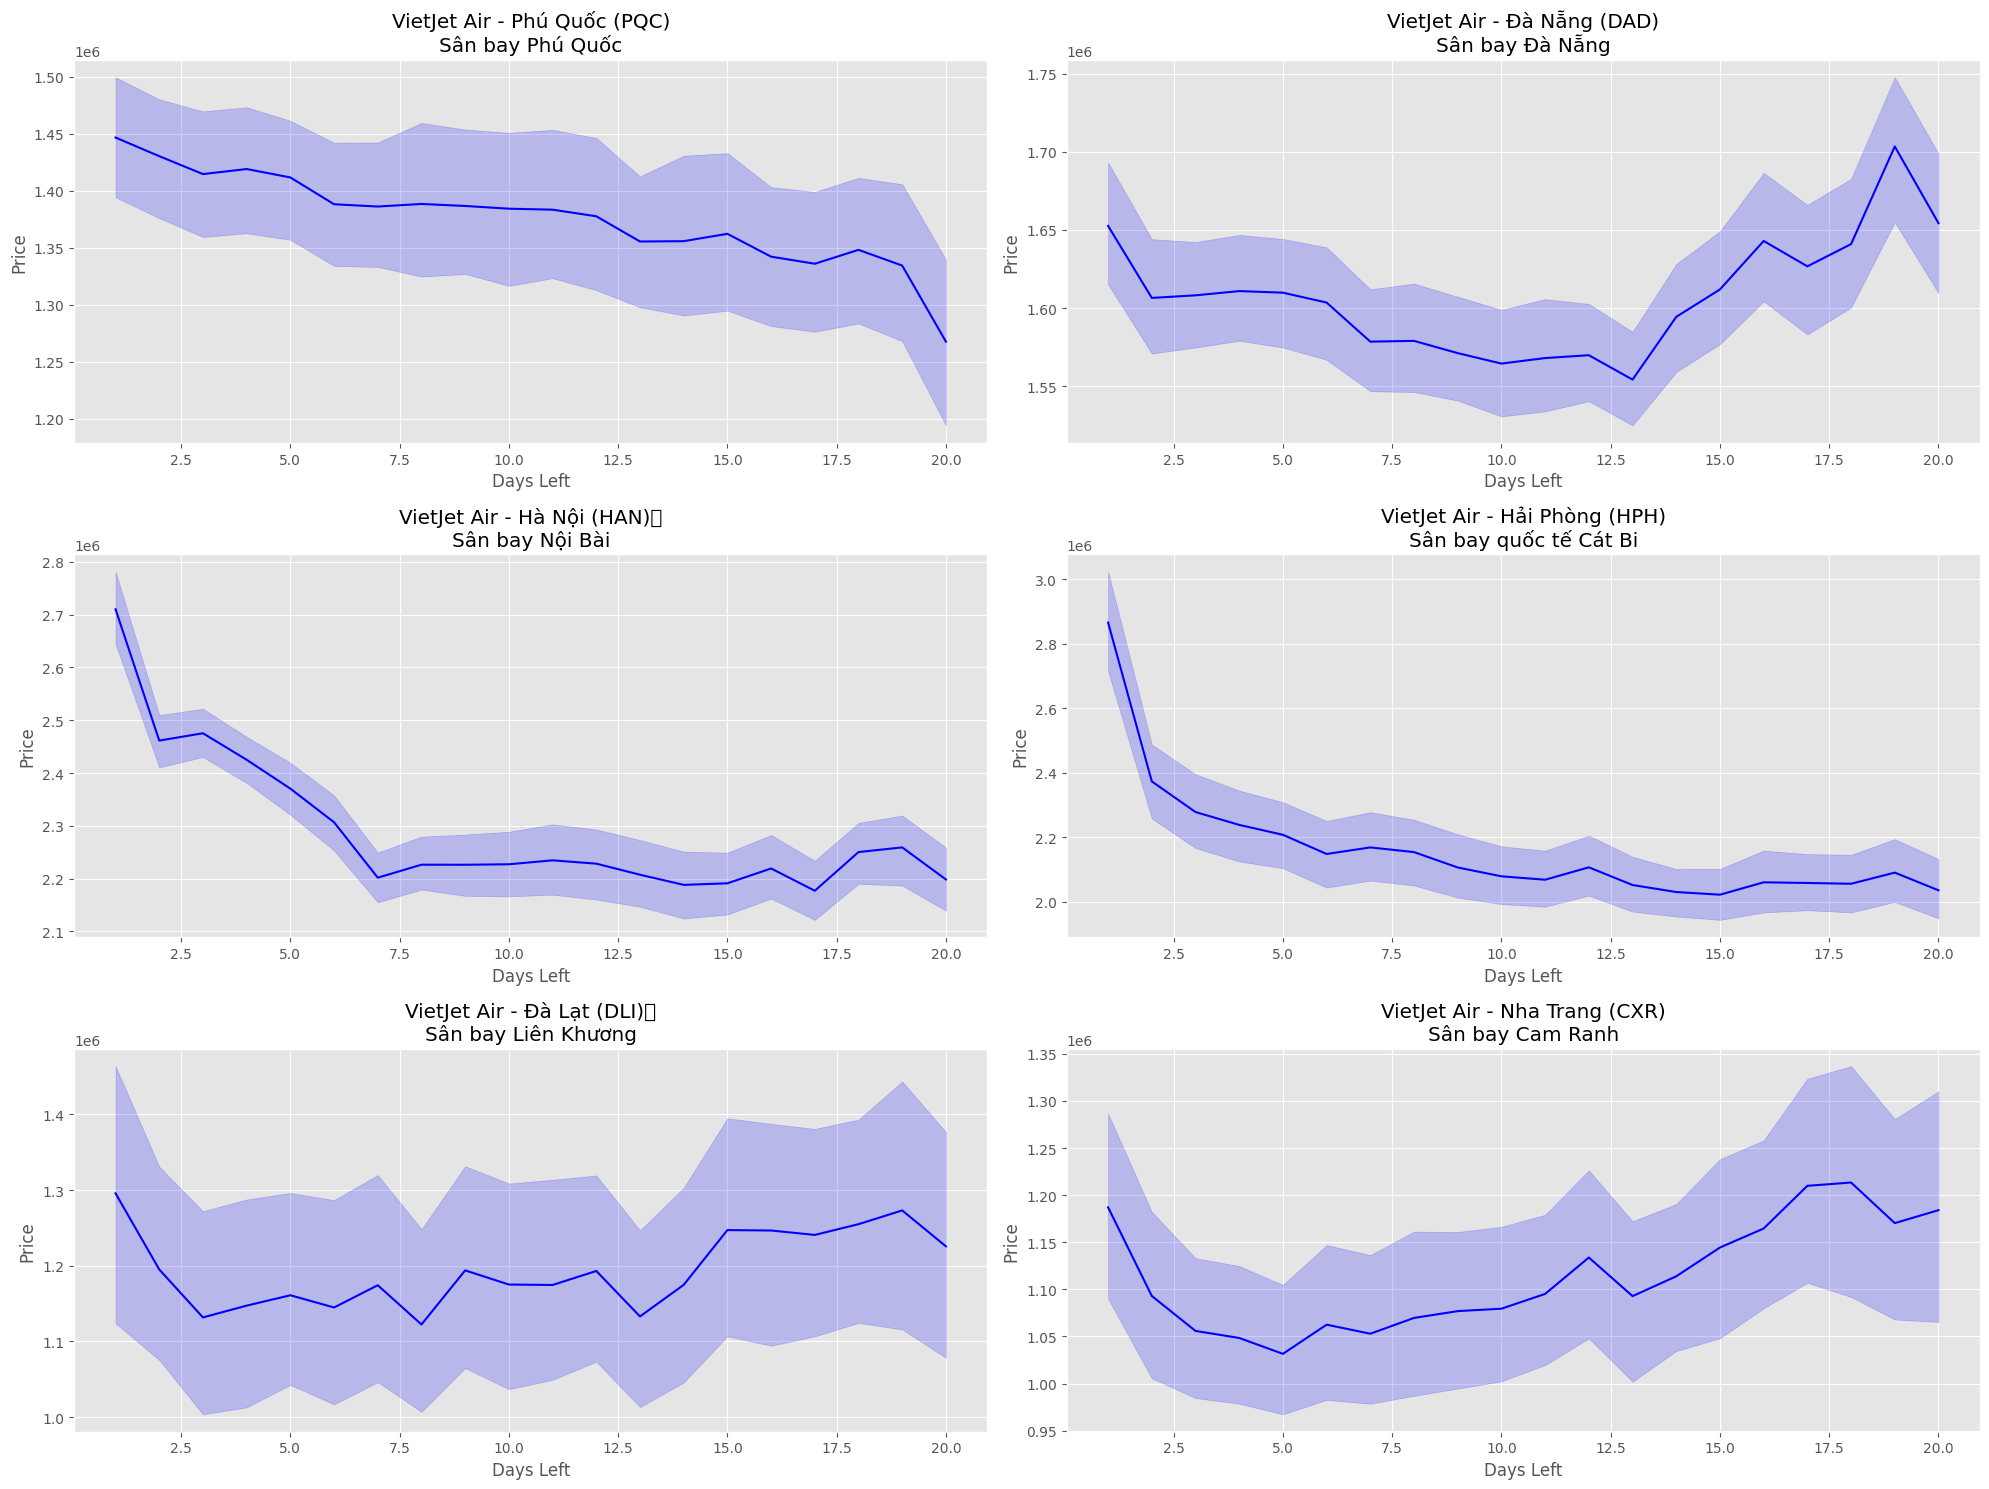

In [13]:
lineplot(Vietjet[Vietjet['days_left'] <= 20])

**Vietnam**

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 2200
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 5856
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 8182
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 1176
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 1124
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 2051


) missing from font(s) DejaVu Sans.ykernel_26500\2195073531.py:22: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


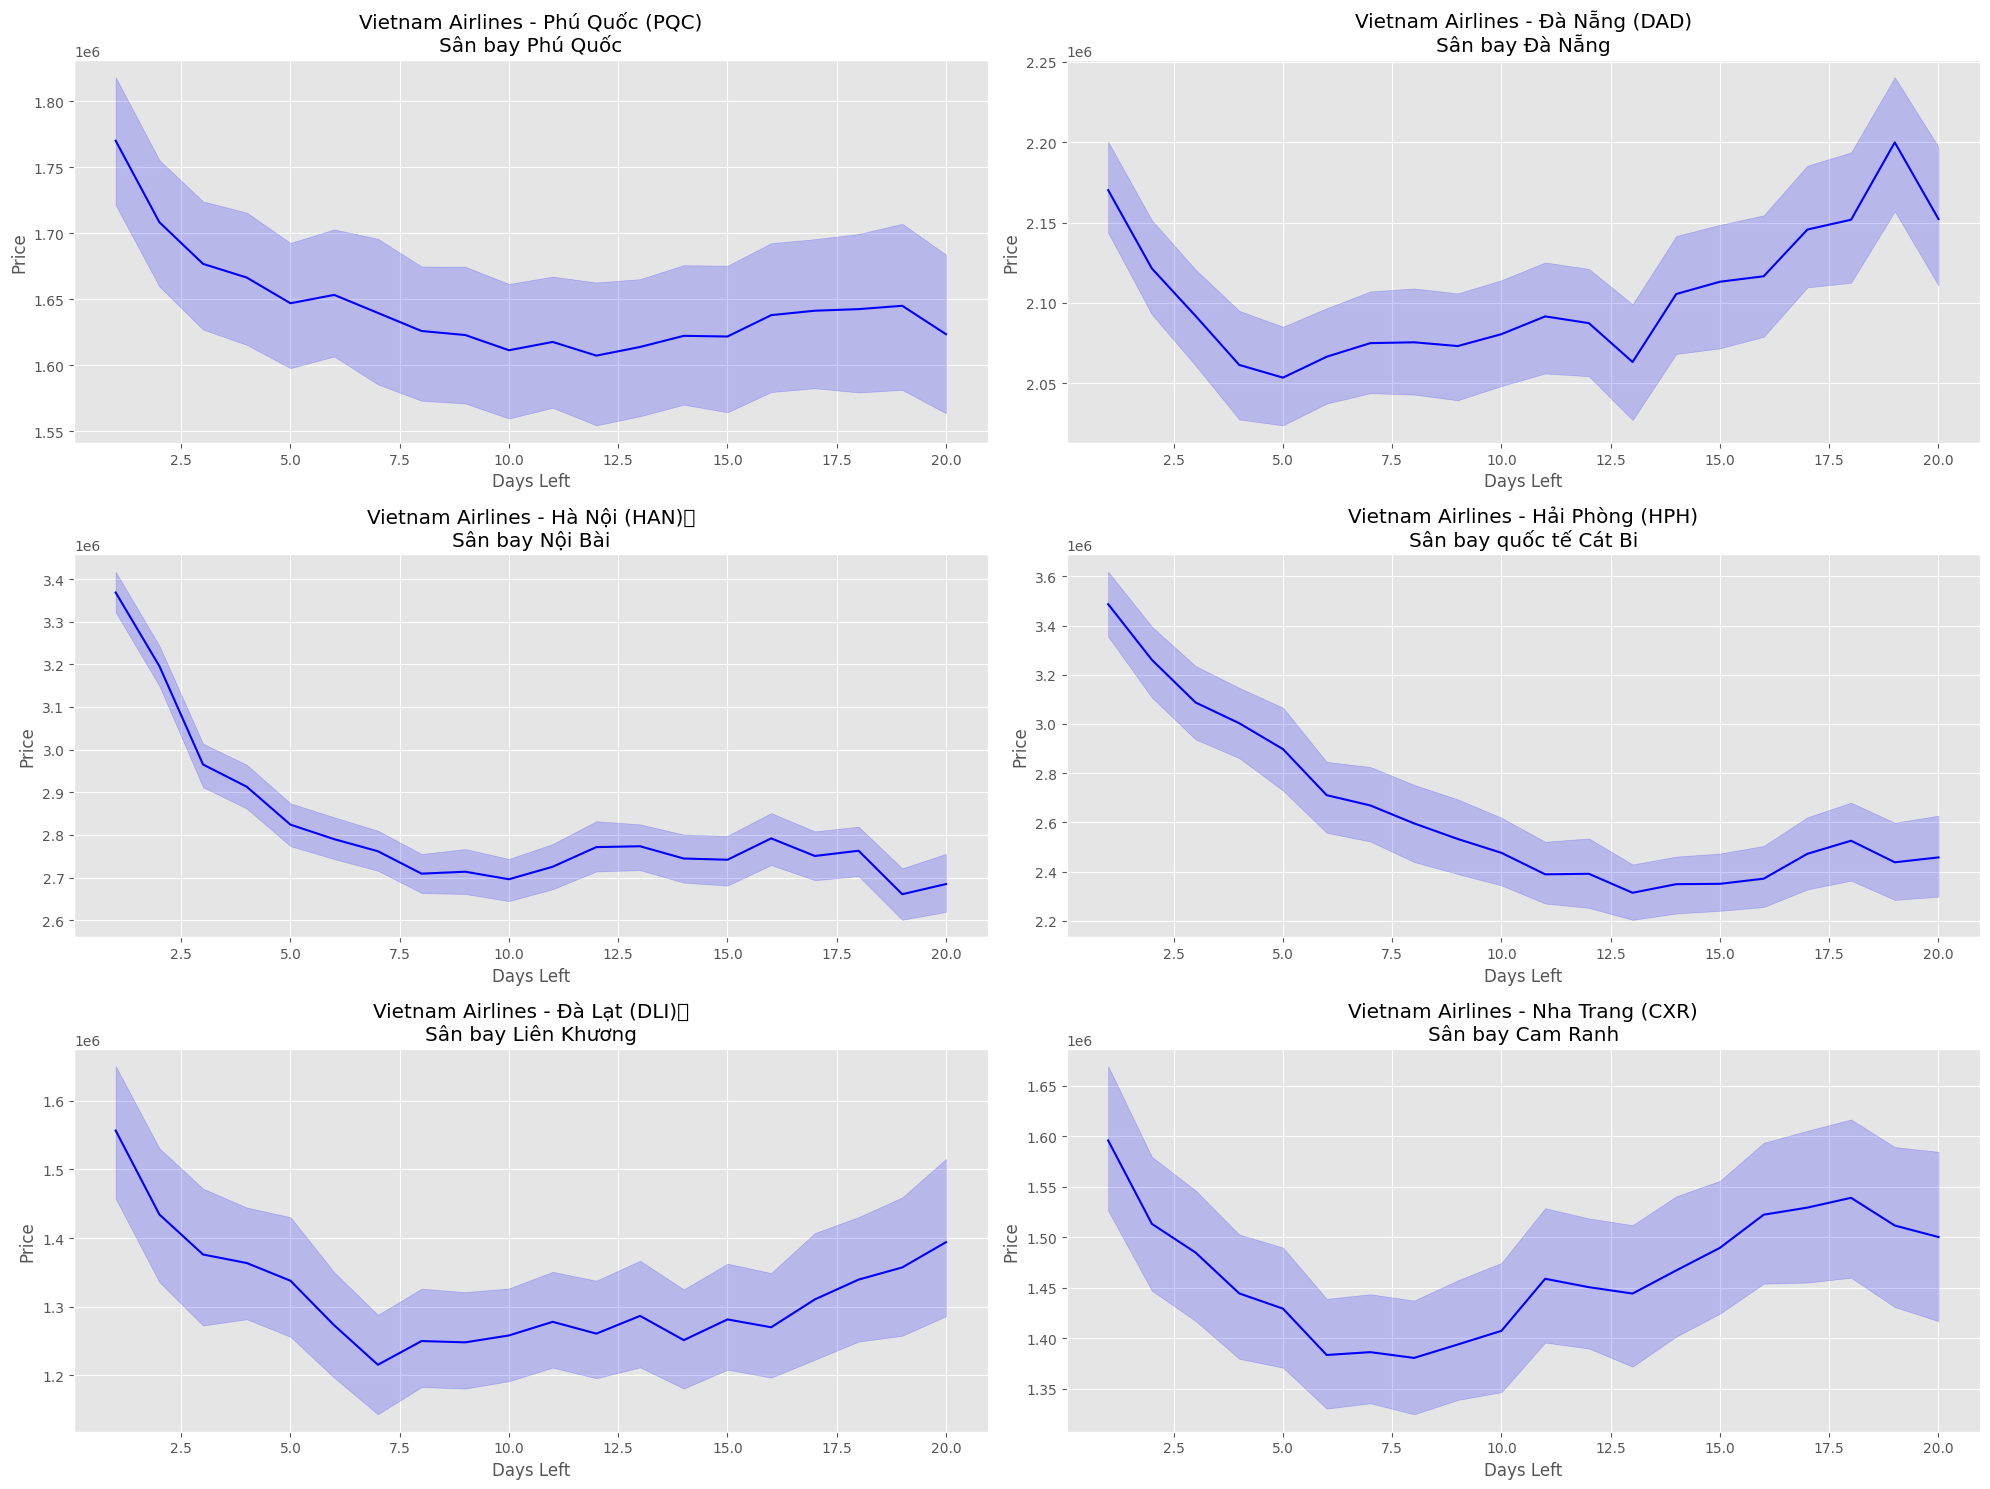

In [14]:
lineplot(Vietnam[Vietnam['days_left'] <= 20])

# TRAIN _ TEST 

In [15]:
len(Bamboo['destination'].unique())

5

In [16]:
data['brand'].unique()

array(['Bamboo Airways', 'Vietravel Airlines', 'Vietnam Airlines',
       'VietJet Air'], dtype=object)

In [17]:
test_data = []

def split_train_test(data):
   train = []
   test = []

   for des in data['destination'].unique():
      df = data[data['destination'] == des]
      for i in range(2):
         id = df['id'].sample(n=1, random_state=42).values[0]
         if df['brand'].unique()[0] == 'Vietravel Airlines':
            days_left = 7
         else:
            days_left = np.random.randint(10, 15)
         flight_by_id = df[(df['id'] == id) & (df['days_left'] <= days_left)]
         test.append(flight_by_id)
         test_data.append(flight_by_id)
         df = df.drop(flight_by_id.index)

      sample_df = df.sample(frac=0.18, random_state=42)
      train.append(df.drop(sample_df.index))
      test.append(sample_df)
   train = pd.concat(train, ignore_index=True)
   test = pd.concat(test, ignore_index=True)
   return train, test

In [18]:
Bamboo_train, Bamboo_test = split_train_test(Bamboo)
Vietjet_train, Vietjet_test = split_train_test(Vietjet)
Vietnam_train, Vietnam_test = split_train_test(Vietnam)
Vietravel_train, Vietravel_test = split_train_test(Vietravel)

In [20]:
Bamboo_train.shape, Bamboo_test.shape, Vietjet_train.shape, Vietjet_test.shape, Vietnam_train.shape, Vietnam_test.shape, Vietravel_train.shape, Vietravel_test.shape

((2524, 23),
 (663, 23),
 (17238, 23),
 (3924, 23),
 (17144, 23),
 (3882, 23),
 (929, 23),
 (245, 23))

# OUTLIERS

In [21]:
def threshold_outlier(des, data):
   df = data[data['destination'] == des]
   q1 = df['price'].quantile(0.25)
   q3 = df['price'].quantile(0.75)
   iqr = q3 - q1
   lower_bound = q1 - 1.5 * iqr
   upper_bound = q3 + 1.5 * iqr
   return lower_bound, upper_bound

In [22]:
def process_outliers(data):
   for des in data['destination'].unique():
      lower, upper = threshold_outlier(des, data)
      condition = (
            (data['destination'] == des) &
            ((data['price'] < lower) | (data['price'] > upper))
      )
      data.loc[condition, 'price'] = upper
   return data

In [23]:
Bamboo_train = process_outliers(Bamboo_train)
Vietjet_train = process_outliers(Vietjet_train)
Vietnam_train = process_outliers(Vietnam_train)
Vietravel_train = process_outliers(Vietravel_train)

C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\611414442.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3892862.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[condition, 'price'] = upper
C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\611414442.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4293867.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[condition, 'price'] = upper
C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\611414442.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3079702.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[condition, 'price'] = upper
C:\User

In [24]:
def boxplot(data):
   for des in data['destination'].unique():
      print(f'Destination: {des}, count: {len(data[data["destination"] == des])}')
      df = data[data['destination'] == des]
   plt.figure(figsize=(15, 5))
   sns.boxplot(x='destination', y='price', data=data, palette='hls')
   plt.title(f'Boxplot of {df['brand'].unique()[0]} by destination')
   plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 191
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 487
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 1527
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 153
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 166


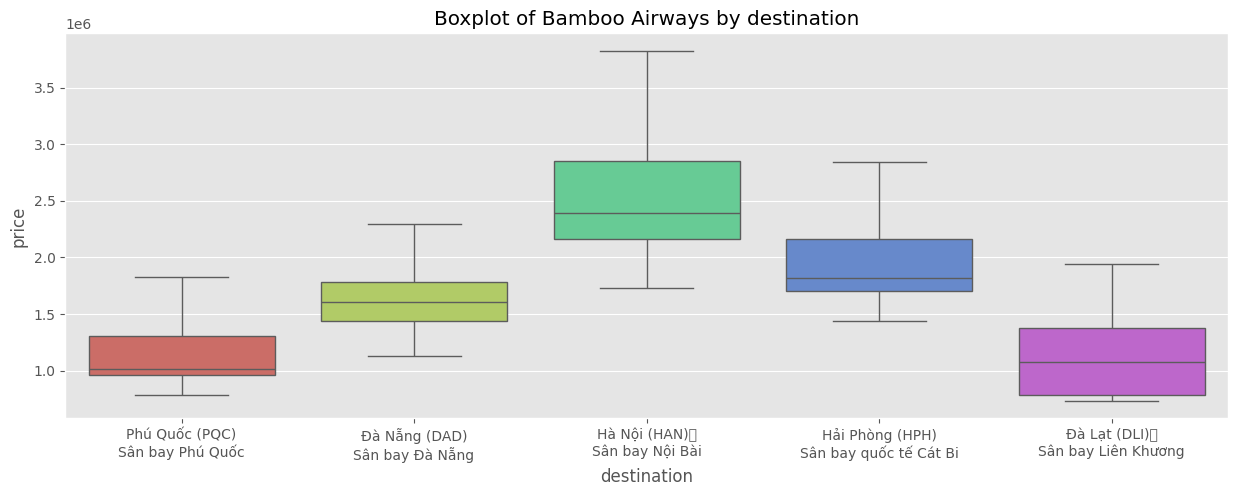

In [25]:
boxplot(Bamboo_train)

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 1891
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 4605
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 7227
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 2233
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 382
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 900


C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


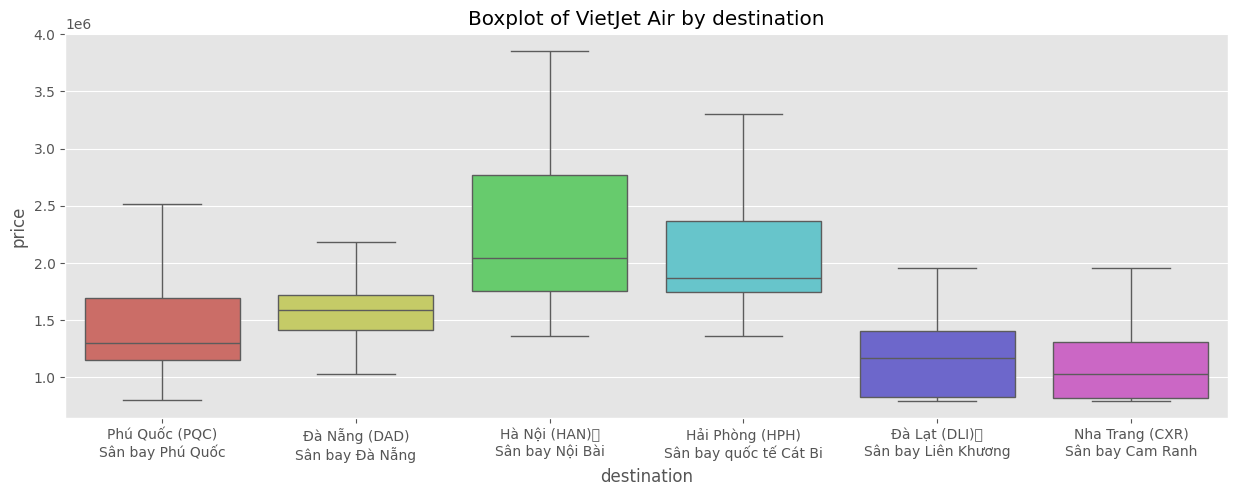

In [26]:
boxplot(Vietjet_train)

C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')


Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 308
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 320
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 301


) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


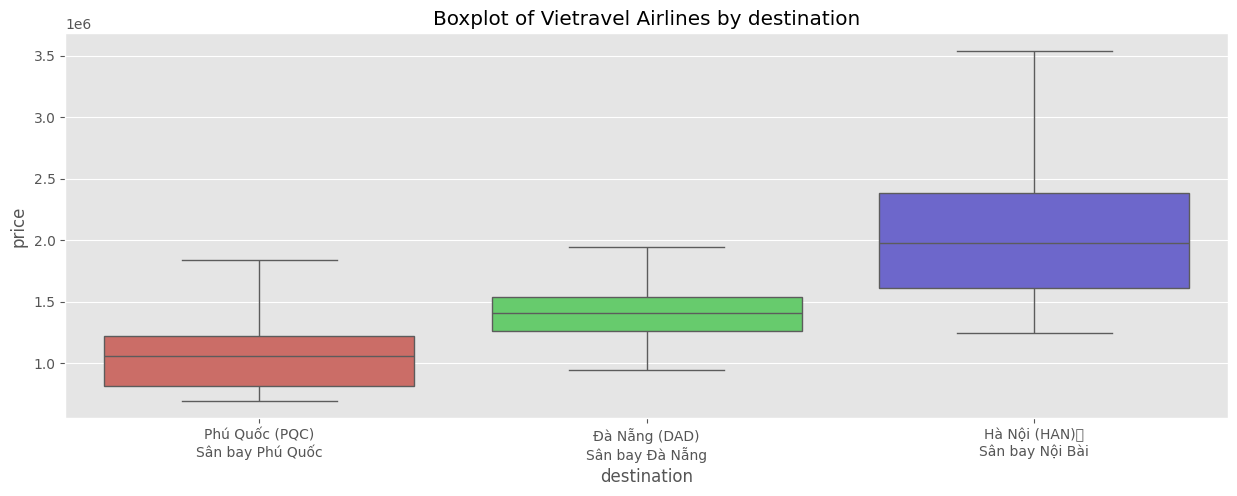

In [27]:
boxplot(Vietravel_train)

Destination: Phú Quốc (PQC)
Sân bay Phú Quốc, count: 1865
Destination: Đà Nẵng (DAD)
Sân bay Đà Nẵng, count: 5015
Destination: Hà Nội (HAN)
Sân bay Nội Bài, count: 6691
Destination: Hải Phòng (HPH)
Sân bay quốc tế Cát Bi, count: 1000
Destination: Đà Lạt (DLI)
Sân bay Liên Khương, count: 903
Destination: Nha Trang (CXR)
Sân bay Cam Ranh, count: 1670


C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\2400653087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='destination', y='price', data=data, palette='hls')
) missing from font(s) DejaVu Sans.n\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


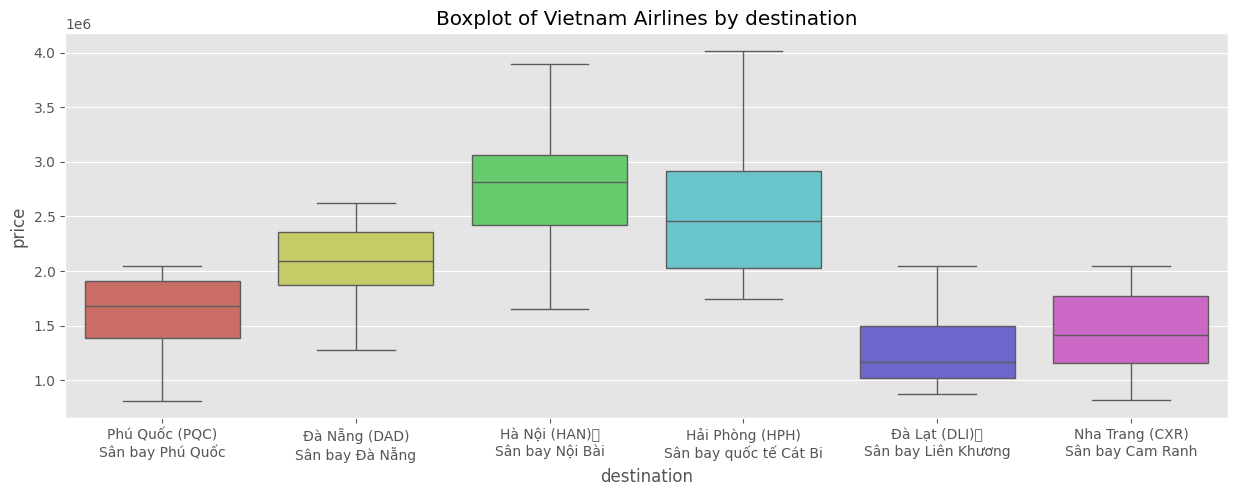

In [28]:
boxplot(Vietnam_train)

# Modeling

In [29]:
from sklearn.preprocessing import StandardScaler

def scale_data(X_train, X_test):
   scaler = StandardScaler()  
   # mmscaler = MinMaxScaler(feature_range=(0, 1))
   X_train = scaler.fit_transform(X_train)
   X_test = scaler.transform(X_test)
   X_train=pd.DataFrame(X_train)
   X_test=pd.DataFrame(X_test)
   return X_train, X_test

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor
import xgboost as xgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

In [31]:
modelAda = AdaBoostRegressor()
modelETR = ExtraTreesRegressor(n_estimators=100)
modelmlg = LinearRegression()
modeldcr = DecisionTreeRegressor()
modelbag = BaggingRegressor()
modelrfr = RandomForestRegressor()
modelXGR = xgb.XGBRegressor()
modelKNN = KNeighborsRegressor(n_neighbors=5)
modelRE=Ridge()
modelLO=linear_model.Lasso(alpha=0.1)
modelGBR = GradientBoostingRegressor()

In [32]:
MM = [modelAda, modelETR, modelmlg, modeldcr, modelrfr, modelKNN, modelGBR, modelXGR, modelbag,modelRE,modelLO]
models=['AdaBoost', 'ExtraTreesRegressor', 'LinearRegression','DecisionTreeRegressor','RandomForestRegressor','KNeighborsRegressor','GradientBoostingRegressor','XGBRegressor','BaggingRegressor','Ridge Regression','Lasso Regression']
def modeling(X_train, X_test, y_train, y_test, Results, brand):
    count = 0
    for model in MM:
        # Fit the model with train data
        model.fit(X_train, y_train)
        
        # Predict the model with test data
        y_pred = model.predict(X_test)
        
        # Print the model name
        # print('Model Name: ', models)
        # print('R2_score:', round(metrics.r2_score(y_test, y_pred),6))
        # print('------------------------------------------------------------------------------------------------------------')
        #-------------------------------------------------------------------------------------------
        new_row = {'Brand' : brand,
                   'Model Name' : models[count],
                   'R2_score' : round(metrics.r2_score(y_test, y_pred),6)}
        Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
        count += 1
    return Results, y_pred

In [33]:
Bamboo_train.head()

,id,brand,price,destination,trip_mins,is_holiday,days_left,start_hour_Afternoon,start_hour_EarlyMorning,start_hour_Evening,start_hour_LateNight,start_hour_Morning,end_hour_Afternoon,end_hour_EarlyMorning,end_hour_Evening,end_hour_LateNight,end_hour_Morning,hand_luggage_7,hand_luggage_10,hand_luggage_12,checked_baggage_0,checked_baggage_20,checked_baggage_23
0,PQC0002,Bamboo Airways,1245267.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,2,1,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
1,PQC0003,Bamboo Airways,869953.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,2,2,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
2,PQC0004,Bamboo Airways,1013756.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,2,3,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
3,PQC0005,Bamboo Airways,782244.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,0,4,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False
4,PQC0007,Bamboo Airways,1222830.0,Phú Quốc (PQC)\nSân bay Phú Quốc,60,1,8,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False


In [34]:
def split_and_model(train, test):
   Results = pd.DataFrame(columns=['Brand', 'Model Name', 'R2_score'])

   # Split the data into features and target variable
   X_train = train.drop(columns=['price', 'brand', 'id'])
   y_train = train['price']
   X_test = test.drop(columns=['price', 'brand', 'id'])
   y_test = test['price']

   # Convert categorical variables to dummy variables
   X_train = pd.get_dummies(X_train, columns=['destination'])
   X_test = pd.get_dummies(X_test, columns=['destination'])

   # Scale the data
   X_train, X_test = scale_data(X_train, X_test)

   # Split and model for each destination
   Results, y_pred = modeling(X_train, X_test, y_train, y_test, Results, train['brand'][0])
   return Results, y_pred

In [35]:
Bamboo_results, Bamboo_pred = split_and_model(Bamboo_train, Bamboo_test)
Vietjet_results, Vietjet_pred = split_and_model(Vietjet_train, Vietjet_test)
Vietravel_results, Vietravel_pred = split_and_model(Vietravel_train, Vietravel_test)
Vietnam_results, Vietnam_pred = split_and_model(Vietnam_train, Vietnam_test)

# Combine all results into a single DataFrame
all_results = pd.concat([Bamboo_results, Vietjet_results, Vietravel_results, Vietnam_results], ignore_index=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\3853082926.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.730e+13, tolerance: 1.309e+11
  model = cd_fast.enet_coordinate_descent(
C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\3853082926.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future ver

In [36]:
pivot_df = all_results.pivot(index='Model Name', columns='Brand', values='R2_score')
pivot_df

Brand,Bamboo Airways,VietJet Air,Vietnam Airlines,Vietravel Airlines
Model Name,,,,
AdaBoost,0.881753,0.697103,0.706650,0.649293
BaggingRegressor,0.894076,0.749600,0.741360,0.665111
DecisionTreeRegressor,0.882245,0.742493,0.733219,0.614984
ExtraTreesRegressor,0.887656,0.743228,0.733875,0.617649
GradientBoostingRegressor,0.915586,0.777305,0.765195,0.723546
KNeighborsRegressor,0.907688,0.708059,0.715263,0.705853
Lasso Regression,0.897670,0.612478,0.678012,0.670265
LinearRegression,0.897900,0.612480,0.678012,0.670265
RandomForestRegressor,0.897377,0.753279,0.746009,0.657156


In [37]:
Bamboo_results, Bamboo_pred = split_and_model(Bamboo_train, Bamboo_test)
Bamboo_results_2 = pd.concat([Bamboo_test['price'], pd.DataFrame(Bamboo_pred, columns=['Predicted Price'])], axis=1)

C:\Users\DELL\AppData\Local\Temp\ipykernel_26500\3853082926.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.730e+13, tolerance: 1.309e+11
  model = cd_fast.enet_coordinate_descent(


In [38]:
Bamboo_results_2['price'] = Bamboo_results_2['price'].apply(lambda x: int(x))
Bamboo_results_2['Predicted Price'] = Bamboo_results_2['Predicted Price'].apply(lambda x: int(x))

Bamboo_results_2 = Bamboo_results_2.sort_values(by='price')
Bamboo_results_2.head()

,price,Predicted Price
620,734450,817087
0,754708,966883
617,754708,830560
1,754708,962392
618,754708,826069


# Predict

In [39]:
def create_data(X):
   expanded_rows = []

   for _, row in X.iterrows():
      for day in range(row['days_left'] - 1, 0, -1):  # giảm từ days_left về 1
         new_row = row.copy()
         new_row['days_left'] = day
         expanded_rows.append(new_row)

   return pd.DataFrame(expanded_rows).reset_index(drop=True)


In [40]:
def adjust(X_test, Y_test):
   for id in X_test['id'].unique():
      y_connt = Y_test[Y_test['id'] == id].value_counts()
      x_connt = X_test[X_test['id'] == id].value_counts()
      if y_connt.equals(x_connt):
         continue
      days_left = Y_test[Y_test['id'] == id]['days_left'].unique()
      X_test = X_test[~((X_test['id'] == id) & ~(X_test['days_left'].isin(days_left)))]
   return X_test

In [41]:
def lineplot_y_pred(data):
   plt.figure(figsize=(20,8))
   sns.lineplot(data=data,x='days_left',y='Actual Price',color='red')
   sns.lineplot(data=data,x='days_left',y='Predicted Price',color='blue')
   plt.title('Days Left For Departure Versus Actual Ticket Price and Predicted Ticket Price',fontsize=20)
   plt.legend(labels=['Actual Price','Predicted Price'],fontsize=19)
   plt.xlabel('Days Left for Departure',fontsize=15)
   plt.ylabel('Actual and Predicted Price',fontsize=15)
   plt.show()

In [42]:
test_data = pd.concat(test_data, ignore_index=True)

In [43]:
def predict(brand, train):
   test = test_data[test_data['brand'] == brand].copy()
   X_test = []
   Y_test = []
   for des in test['destination'].unique():
      for id in test['id'].unique():
         df = test[(test['destination'] == des) & (test['id'] == id)].copy().sort_values(by='days_left', ascending=False)
         X_test.append(df.head(1))
         df = df.drop(df.head(1).index)
         Y_test.append(df)

   X_test = pd.concat(X_test, ignore_index=True)
   Y_test = pd.concat(Y_test, ignore_index=True)

   X_test = create_data(X_test)
   X_test = adjust(X_test, Y_test)

   X_test = X_test.drop(columns=['id', 'brand', 'price'])
   Y_test = Y_test['price']

   X_train = train.drop(columns=['price', 'brand', 'id'])
   y_train = train['price']

   X_test_model = pd.get_dummies(X_test, columns=['destination'])
   X_train = pd.get_dummies(X_train, columns=['destination'])

   X_train_scaled, X_test_scaled = scale_data(X_train, X_test_model)

   modelGBR.fit(X_train_scaled, y_train)

   y_pred = modelGBR.predict(X_test_scaled)
   output = pd.DataFrame({'Actual Price': Y_test, 'Predicted Price': y_pred}, index=Y_test.index)

   result = X_test.copy()
   result['Actual Price'] = output['Actual Price']
   result['Predicted Price'] = output['Predicted Price']

   print(f'Brand: {brand}, R2_score: {round(metrics.r2_score(Y_test, y_pred), 6)}')
   lineplot_y_pred(result)

   return result

Brand: Bamboo Airways, R2_score: 0.956606


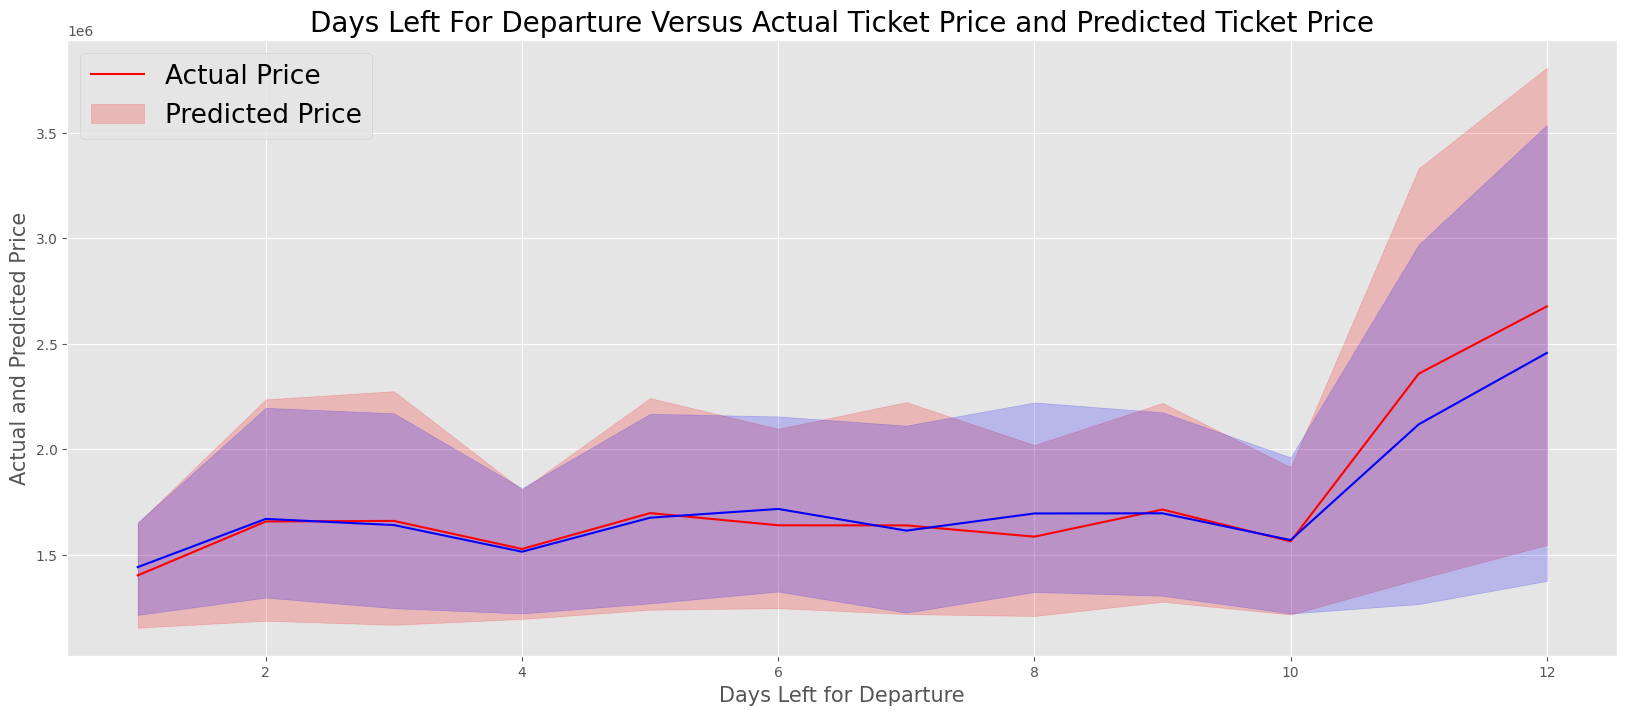

In [44]:
Bamboo_predicted = predict('Bamboo Airways', Bamboo_train)

Brand: VietJet Air, R2_score: 0.868775


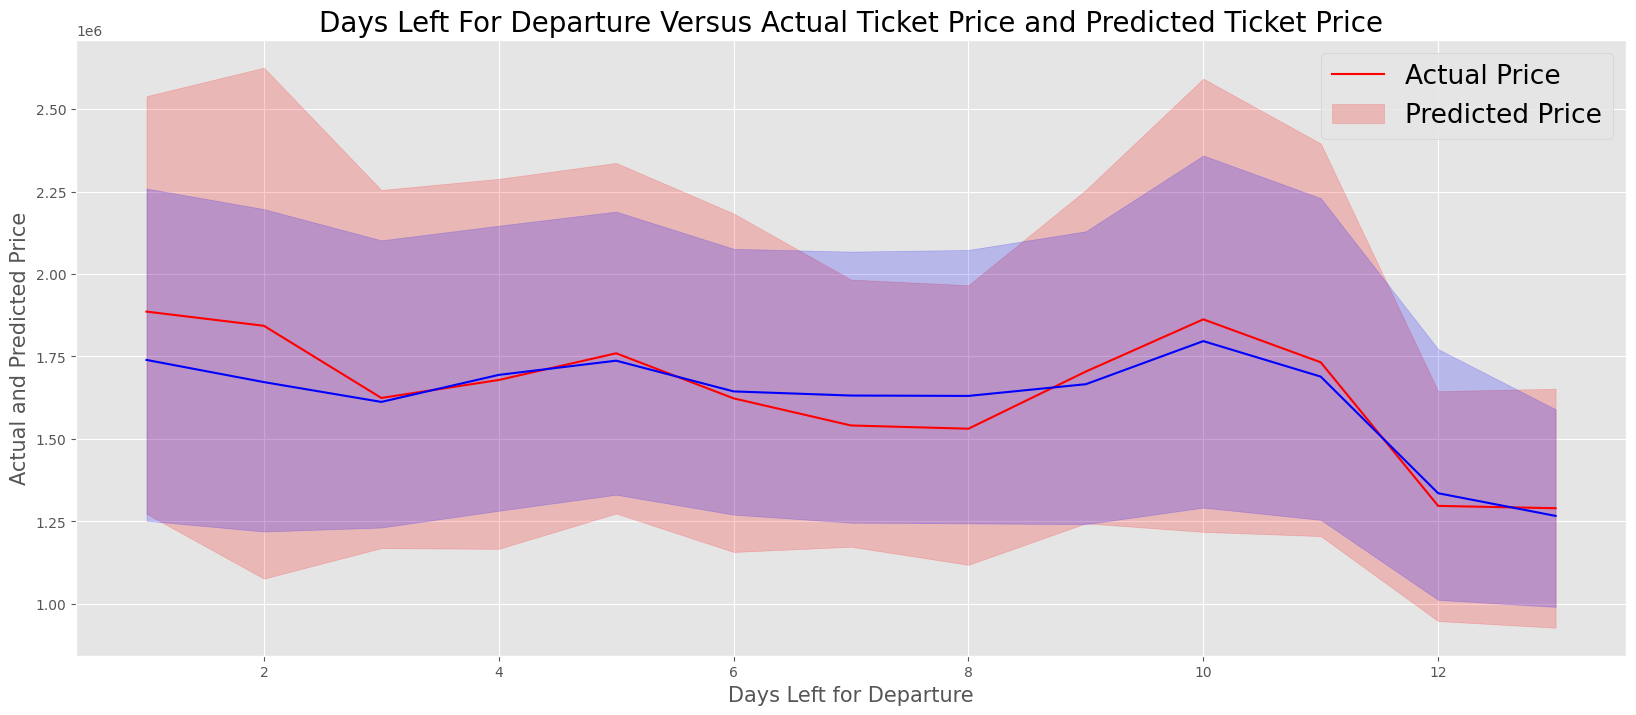

In [45]:
Vietjet_predicted = predict('VietJet Air', Vietjet_train)

Brand: Vietnam Airlines, R2_score: 0.770038


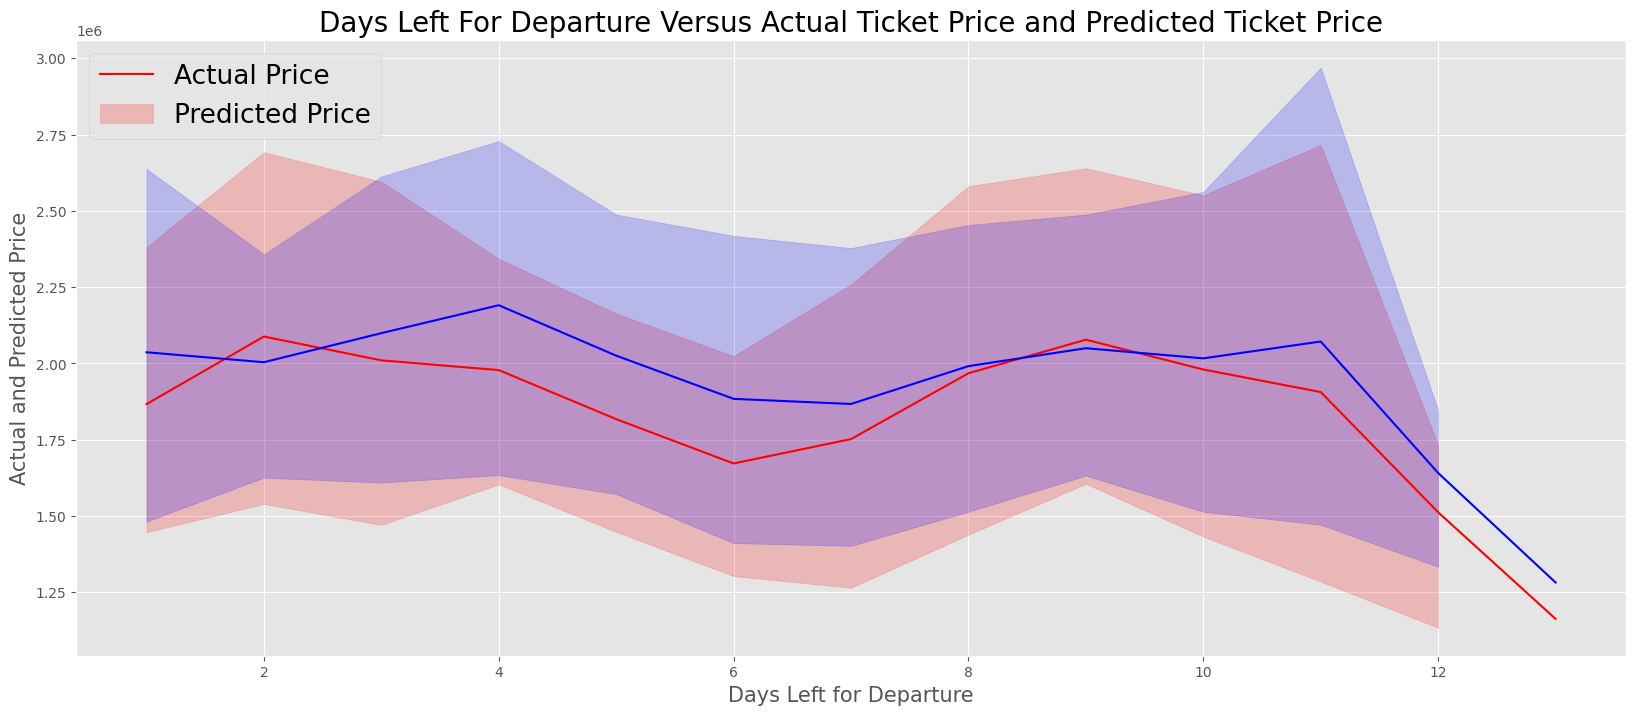

In [46]:
Vietnam_predicted = predict('Vietnam Airlines', Vietnam_train)

Brand: Vietravel Airlines, R2_score: 0.748937


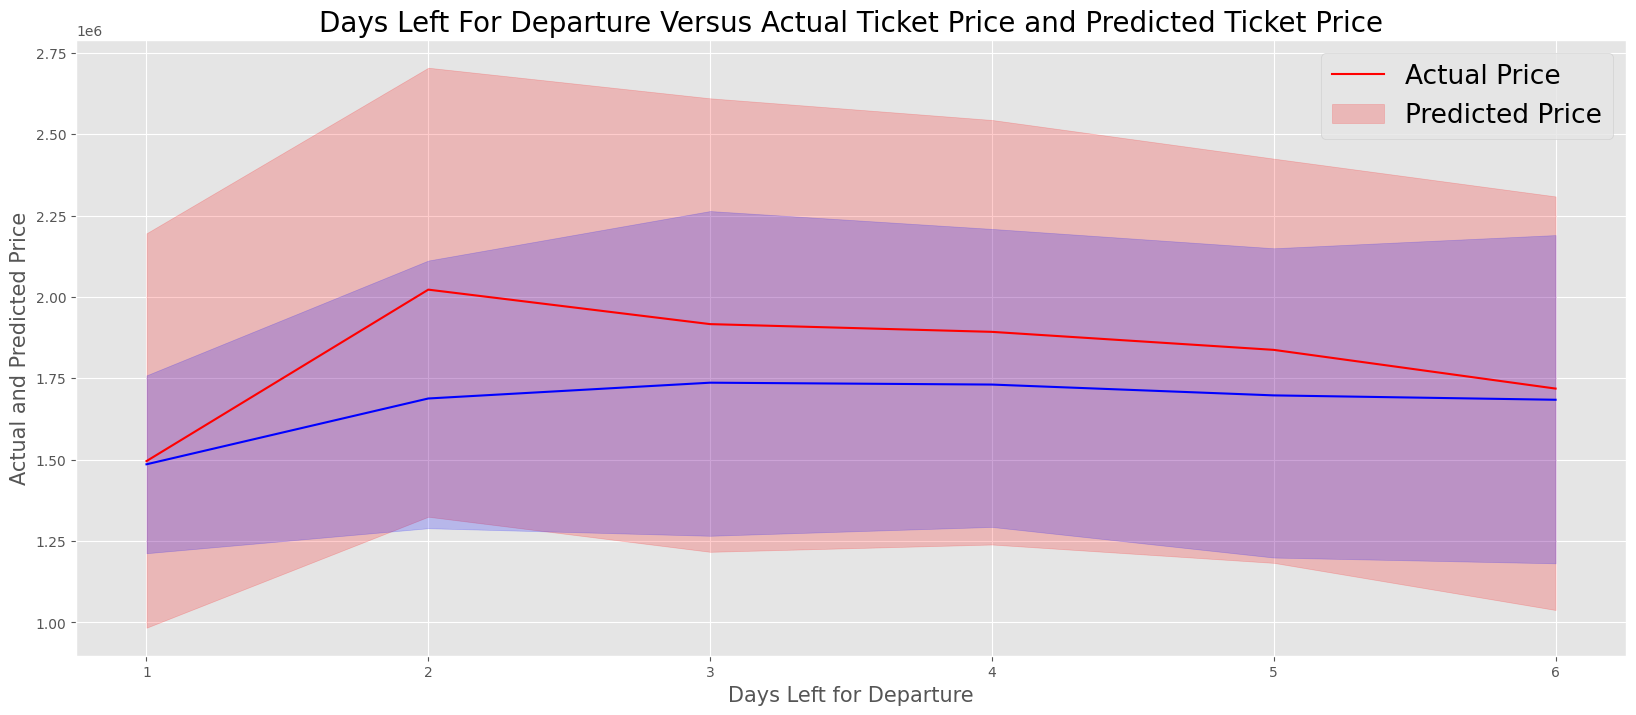

In [47]:
Vietravel_predicted = predict('Vietravel Airlines', Vietravel_train)